In [ ]:
# # Clasificador binario de imágenes con ConcNeXT-tiny
#
# Caso: detectar datos de contacto en imágenes de publicaciones de e-commerce.
#
# **Dataset esperado:**
#
# ```text
# dataset_imagenes/
# ├── train/
# │   ├── images/
# │   └── train.csv
# └── test/
#     ├── images/
#     └── test.csv
# ```
#
# **CSV esperado, mínimo:**
#
# ```csv
# image_path,label
# images/train_000001.jpg,0
# train/images/train_000001.jpg,0
# ```
#
# El código contempla ambas variantes de path. Como el dataset no trae validación, se crea una validación interna desde `train.csv`. El conjunto `test` queda reservado para evaluación final.


In [ ]:
# ## 1. Imports

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt


In [ ]:
# ## 2. Configuración general
#
# Ajustar principalmente:
#
# - `DRIVE_ARCHIVE_PATH`: ruta del `.tar.gz` o `.zip` en Google Drive.
# - `IMG_SIZE`: 384 para la corrida seria; 224 para prueba rápida.
# - `BATCH_SIZE`: si hay error de memoria, bajar a 16.

In [ ]:
SEED = 42
IMG_SIZE = 384
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR_BACKBONE = 5e-4
LR_CLASSIFIER = 5e-3
NUM_WORKERS = 4
VAL_SIZE = 0.15
EARLY_STOPPING_PATIENCE = 5
MIN_PRECISION_FOR_THRESHOLD = 0.70

DRIVE_ARCHIVE_PATH = Path("/content/drive/MyDrive/TP Vision por Computadora 2/dataset_imagenes.tar.gz")

LOCAL_ROOT = Path("/content")
DATASET_DIR = LOCAL_ROOT / "dataset_imagenes"

OUTPUT_DIR = Path("/content/drive/MyDrive/TP Vision por Computadora 2/outputs_convnext_tiny")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

Device: cuda


In [ ]:
# ## 3. Montar Drive y descomprimir dataset a `/content`
#
# Drive se usa como almacenamiento persistente. El entrenamiento lee desde `/content`, que es más rápido.

from google.colab import drive

mountpoint = Path("/content/drive")

if not os.path.ismount(str(mountpoint)):
    if mountpoint.exists() and any(mountpoint.iterdir()):
        print("/content/drive contiene archivos locales antes del mount. Se elimina ese directorio local para poder montar Drive.")
        shutil.rmtree(mountpoint)
    drive.mount(str(mountpoint))
else:
    print("Drive ya está montado en:", mountpoint)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    print("Descomprimiendo dataset en /content...")
    shutil.unpack_archive(str(DRIVE_ARCHIVE_PATH), str(LOCAL_ROOT))
else:
    print("Dataset ya existe en:", DATASET_DIR)

print("Contenido dataset:")
print(list(DATASET_DIR.iterdir()))

Mounted at /content/drive
Descomprimiendo dataset en /content...
Contenido dataset:
[PosixPath('/content/dataset_imagenes/train'), PosixPath('/content/dataset_imagenes/test')]


In [ ]:
# ## 4. Revisión rápida de CSVs

train_csv = DATASET_DIR / "train" / "train.csv"
test_csv = DATASET_DIR / "test" / "test.csv"

train_full_df = pd.read_csv(train_csv).reset_index(drop=True)
test_df = pd.read_csv(test_csv).reset_index(drop=True)

print("Train original:", train_full_df.shape)
display(train_full_df.head())

print("Test:", test_df.shape)
display(test_df.head())

print("Distribución train original:")
display(pd.concat([
    train_full_df["label"].value_counts().rename("count"),
    train_full_df["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))

print("Distribución test:")
display(pd.concat([
    test_df["label"].value_counts().rename("count"),
    test_df["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))

Train original: (10058, 3)


,image_path,label,image_url
0,train/images/train_000000.jpg,1,https://http2.mlstatic.com/D_686368-MLA9950728...
1,train/images/train_000001.jpg,1,https://http2.mlstatic.com/D_805429-MRD1061207...
2,train/images/train_000002.jpg,1,https://http2.mlstatic.com/D_737563-MBO1108603...
3,train/images/train_000003.jpg,1,https://http2.mlstatic.com/D_933332-MLA1099553...
4,train/images/train_000004.jpg,1,https://http2.mlstatic.com/D_607558-MLA1096698...


Test: (2700, 3)


,image_path,label,image_url
0,test/images/test_000000.jpg,1,https://http2.mlstatic.com/D_751818-MLM5314565...
1,test/images/test_000001.jpg,0,https://http2.mlstatic.com/D_945336-MCO1002118...
2,test/images/test_000002.jpg,1,https://http2.mlstatic.com/D_604807-MLA5250254...
3,test/images/test_000003.jpg,0,https://http2.mlstatic.com/D_678120-MLA9295763...
4,test/images/test_000004.jpg,1,https://http2.mlstatic.com/D_956312-CBT1024094...


Distribución train original:


,count,proportion
label,,
0,8491,0.844204
1,1567,0.155796


Distribución test:


,count,proportion
label,,
0,2504,0.927407
1,196,0.072593


In [ ]:
# ## 5. Crear split `train` / `val` desde el train original
#
# Se mantiene intacto el test para evaluación final.

train_idx, val_idx = train_test_split(
    np.arange(len(train_full_df)),
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_full_df["label"],
)

print("Split interno:")
print("train interno:", len(train_idx))
print("val interno:", len(val_idx))

print("Distribución train interno:")
display(pd.concat([
    train_full_df.iloc[train_idx]["label"].value_counts().rename("count"),
    train_full_df.iloc[train_idx]["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))

print("Distribución val interno:")
display(pd.concat([
    train_full_df.iloc[val_idx]["label"].value_counts().rename("count"),
    train_full_df.iloc[val_idx]["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))


Split interno:
train interno: 8549
val interno: 1509
Distribución train interno:


,count,proportion
label,,
0,7217,0.844192
1,1332,0.155808


Distribución val interno:


,count,proportion
label,,
0,1274,0.844268
1,235,0.155732


In [ ]:
# ## 6. Dataset PyTorch

class ContactImageDataset(Dataset):
    def __init__(self, root_dir, csv_name, transform=None):
        self.root_dir = Path(root_dir)
        self.df = pd.read_csv(self.root_dir / csv_name).reset_index(drop=True)
        self.transform = transform

        required_cols = {"image_path", "label"}
        missing = required_cols - set(self.df.columns)
        if missing:
            raise ValueError(f"Faltan columnas en {csv_name}: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(str(row["image_path"]))

        # El CSV puede traer paths relativos a la carpeta del split:
        #   images/train_000001.jpg
        # o relativos a la raíz del dataset:
        #   train/images/train_000001.jpg
        img_path = self.root_dir / image_path
        if not img_path.exists():
            img_path_alt = self.root_dir.parent / image_path
            if img_path_alt.exists():
                img_path = img_path_alt

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error abriendo imagen: {img_path}") from e

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
# ## 7. Transformaciones y DataLoaders
#
# Para entrenamiento usamos aumentos suaves. Para validación y test no usamos aumentos.

weights = ConvNeXt_Tiny_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_full_ds_for_train = ContactImageDataset(DATASET_DIR / "train", "train.csv", transform=train_transform)
train_full_ds_for_val = ContactImageDataset(DATASET_DIR / "train", "train.csv", transform=val_transform)
test_ds = ContactImageDataset(DATASET_DIR / "test", "test.csv", transform=val_transform)

train_ds = Subset(train_full_ds_for_train, train_idx)
val_ds = Subset(train_full_ds_for_val, val_idx)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))


Batches train: 268
Batches val: 48
Batches test: 85


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


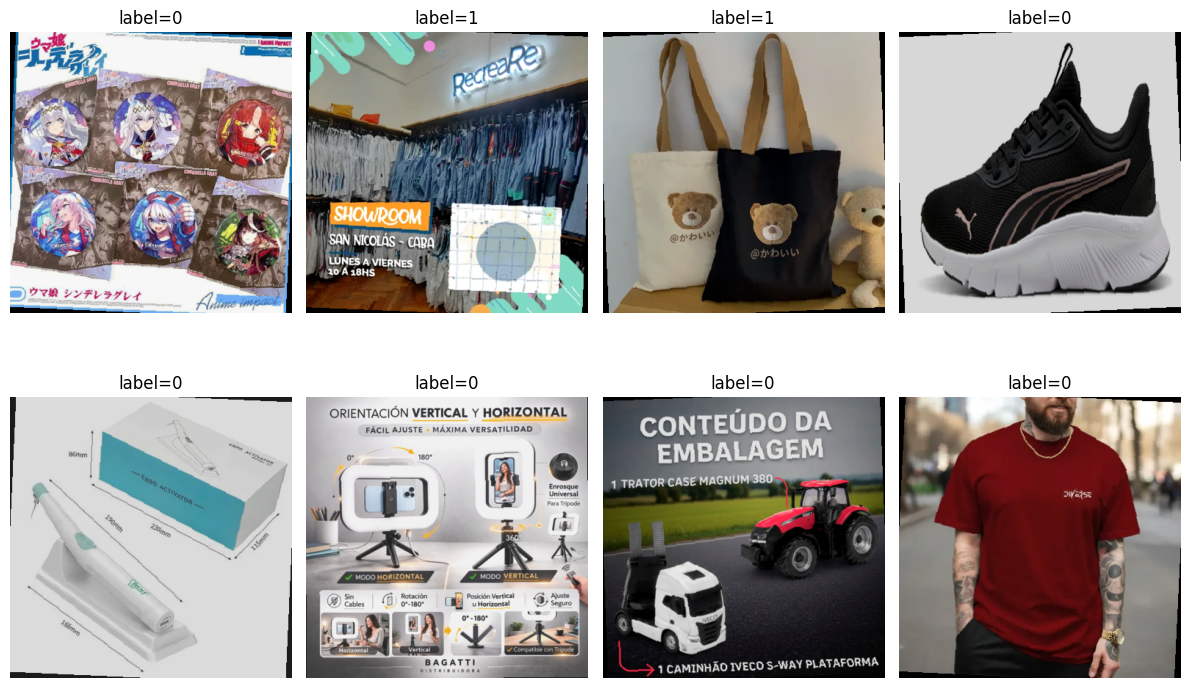

In [ ]:
# ## 8. Visualización rápida de un batch
#
# Sirve para verificar que los paths y transformaciones funcionan.

def denormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor.cpu() * std + mean


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    img = denormalize(images[i], imagenet_mean, imagenet_std).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"label={int(labels[i].item())}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# ## 9. Modelo ConvNeXT-tiny
#
# Usamos pesos preentrenados y reemplazamos la última capa por una salida binaria.

model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 1)
model = model.to(DEVICE)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 129MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1, bias=True)
)


In [ ]:
# ## 10. Loss, optimizador y scheduler
#
# Usamos `pos_weight` suavizado porque el train tiene muchos más positivos que el test. Esto evita empujar demasiado al modelo a predecir positivo.

train_internal_df = train_full_df.iloc[train_idx]
num_pos = (train_internal_df["label"] == 1).sum()
num_neg = (train_internal_df["label"] == 0).sum()
pos_weight_value = np.sqrt(num_neg / max(num_pos, 1))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

print(f"num_pos={num_pos}, num_neg={num_neg}, pos_weight_suavizado={pos_weight_value:.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.SGD(
    [
        {"params": model.features.parameters(), "lr": LR_BACKBONE},
        {"params": model.classifier.parameters(), "lr": LR_CLASSIFIER},
    ],
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

num_pos=1332, num_neg=7217, pos_weight_suavizado=2.328


In [ ]:
# ## 11. Funciones de entrenamiento y evaluación

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).view(-1, 1)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        y_true = labels.detach().cpu().numpy().ravel()

        total_loss += loss.item() * images.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(y_true.tolist())

    avg_loss = total_loss / len(loader.dataset)
    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)

    return avg_loss, all_labels, all_probs


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )

    beta = 2
    if precision + recall == 0:
        f2 = 0.0
    else:
        f2 = (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)

    try:
        auc_pr = average_precision_score(y_true, y_prob)
    except Exception:
        auc_pr = np.nan

    try:
        auc_roc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc_roc = np.nan

    cm = confusion_matrix(y_true, y_pred)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "auc_pr": auc_pr,
        "auc_roc": auc_roc,
        "cm": cm,
    }


In [ ]:
# ## 12. Entrenamiento
#
# Se guarda el mejor modelo según `val_loss`. Hay early stopping si no mejora durante `EARLY_STOPPING_PATIENCE` epochs.

best_val_loss = float("inf")
best_model_path = OUTPUT_DIR / "best_convnext_tiny.pt"

history = []
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_y, train_p = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_y, val_p = run_one_epoch(model, val_loader, optimizer=None)

    train_metrics = compute_metrics(train_y, train_p, threshold=0.5)
    val_metrics = compute_metrics(val_y, val_p, threshold=0.5)

    scheduler.step(val_loss)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_auc_pr": train_metrics["auc_pr"],
        "val_auc_pr": val_metrics["auc_pr"],
        "train_recall": train_metrics["recall"],
        "val_recall": val_metrics["recall"],
        "train_precision": train_metrics["precision"],
        "val_precision": val_metrics["precision"],
        "val_f2": val_metrics["f2"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print("-" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
    print(
        f"val_auc_pr={val_metrics['auc_pr']:.4f} | "
        f"val_auc_roc={val_metrics['auc_roc']:.4f} | "
        f"val_precision={val_metrics['precision']:.4f} | "
        f"val_recall={val_metrics['recall']:.4f} | "
        f"val_f2={val_metrics['f2']:.4f}"
    )
    print("Confusion matrix val @ threshold=0.5:")
    print(val_metrics["cm"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_loss": float(best_val_loss),
            "val_auc_pr": float(val_metrics["auc_pr"]),
            "img_size": IMG_SIZE,
            "model_name": "convnext_tiny",
            "threshold": None,
        }, best_model_path)
        print("Nuevo mejor modelo guardado en:", best_model_path)
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora en val_loss por {epochs_without_improvement} epoch(s).")
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping activado.")
            break

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)
print("Historial guardado en:", history_path)

--------------------------------------------------------------------------------
Epoch 1/30
train_loss=0.6555 | val_loss=0.6132
val_auc_pr=0.4865 | val_auc_roc=0.7784 | val_precision=0.7089 | val_recall=0.2383 | val_f2=0.2748
Confusion matrix val @ threshold=0.5:
[[1251   23]
 [ 179   56]]
Nuevo mejor modelo guardado en: /content/drive/MyDrive/TP Vision por Computadora 2/outputs_convnext_tiny/best_convnext_tiny.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--------------------------------------------------------------------------------
Epoch 2/30
train_loss=0.5902 | val_loss=0.5743
val_auc_pr=0.5222 | val_auc_roc=0.7952 | val_precision=0.5260 | val_recall=0.3447 | val_f2=0.3702
Confusion matrix val @ threshold=0.5:
[[1201   73]
 [ 154   81]]
Nuevo mejor modelo guardado en: /content/drive/MyDrive/TP Vision por Computadora 2/outputs_convnext_tiny/best_convnext_tiny.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--------------------------------------------------------------------------------
Epoch 3/30
train_loss=0.5583 | val_loss=0.5501
val_auc_pr=0.5565 | val_auc_roc=0.8194 | val_precision=0.5266 | val_recall=0.4213 | val_f2=0.4388
Confusion matrix val @ threshold=0.5:
[[1185   89]
 [ 136   99]]
Nuevo mejor modelo guardado en: /content/drive/MyDrive/TP Vision por Computadora 2/outputs_convnext_tiny/best_convnext_tiny.pt


...

--------------------------------------------------------------------------------
Epoch 9/30
train_loss=0.3828 | val_loss=0.8051
val_auc_pr=0.6220 | val_auc_roc=0.8607 | val_precision=0.2927 | val_recall=0.9106 | val_f2=0.6403
Confusion matrix val @ threshold=0.5:
[[757 517]
 [ 21 214]]
Sin mejora en val_loss por 3 epoch(s).


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--------------------------------------------------------------------------------
Epoch 10/30
train_loss=0.3071 | val_loss=0.5142
val_auc_pr=0.6736 | val_auc_roc=0.8692 | val_precision=0.4920 | val_recall=0.6553 | val_f2=0.6145
Confusion matrix val @ threshold=0.5:
[[1115  159]
 [  81  154]]
Sin mejora en val_loss por 4 epoch(s).


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--------------------------------------------------------------------------------
Epoch 11/30
train_loss=0.2833 | val_loss=0.5459
val_auc_pr=0.6880 | val_auc_roc=0.8743 | val_precision=0.6650 | val_recall=0.5574 | val_f2=0.5761
Confusion matrix val @ threshold=0.5:
[[1208   66]
 [ 104  131]]
Sin mejora en val_loss por 5 epoch(s).
Early stopping activado.
Historial guardado en: /content/drive/MyDrive/TP Vision por Computadora 2/outputs_convnext_tiny/training_history.csv


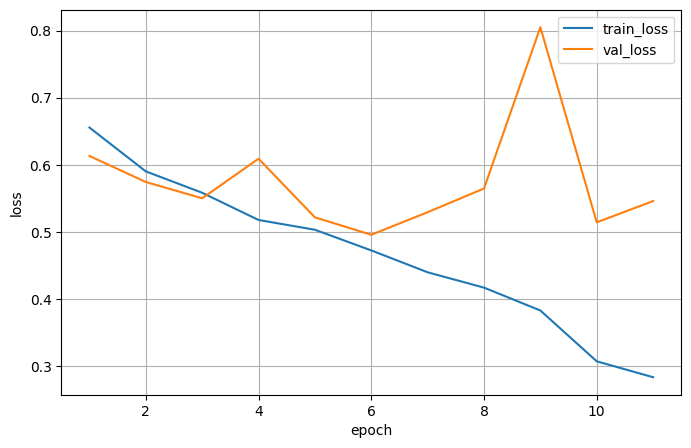

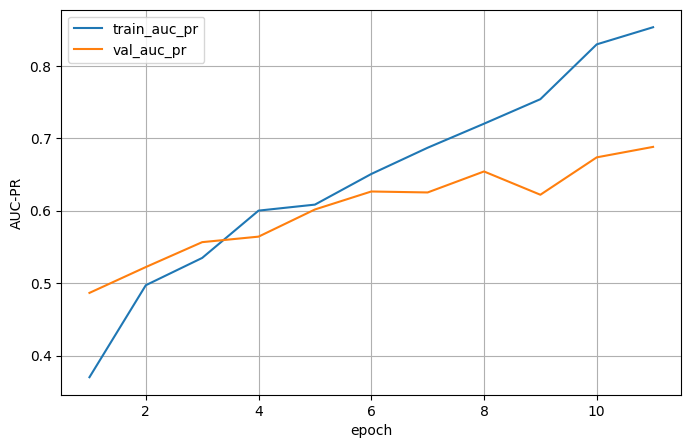

In [ ]:
# ## 13. Curvas simples de entrenamiento

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_auc_pr"], label="train_auc_pr")
plt.plot(history_df["epoch"], history_df["val_auc_pr"], label="val_auc_pr")
plt.xlabel("epoch")
plt.ylabel("AUC-PR")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Mejor threshold en validación interna:
Criterio: max recall con precision >= 0.7
threshold    0.710000
precision    0.714286
recall       0.361702
f1           0.480226
f2           0.401322
Name: 66, dtype: float64


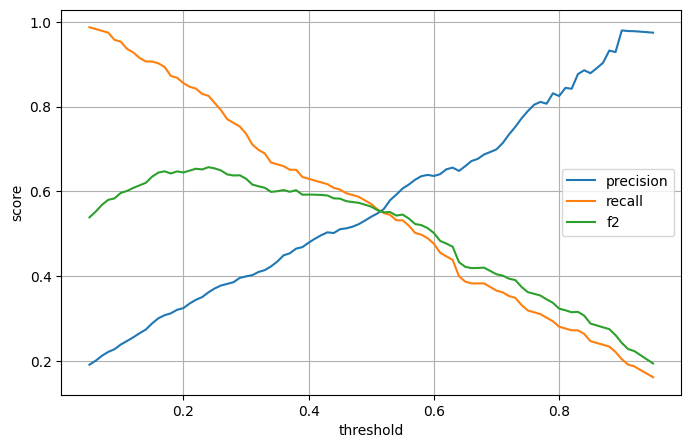

In [ ]:
# ## 14. Buscar umbral óptimo en validación interna
#
# Priorizamos recall, pero solo entre thresholds con precision mínima aceptable.

checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

val_loss, val_y, val_p = run_one_epoch(model, val_loader, optimizer=None)

thresholds = np.linspace(0.05, 0.95, 91)
rows = []

for th in thresholds:
    m = compute_metrics(val_y, val_p, threshold=th)
    rows.append({
        "threshold": th,
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "f2": m["f2"],
    })

threshold_df = pd.DataFrame(rows)
threshold_path = OUTPUT_DIR / "threshold_search_val.csv"
threshold_df.to_csv(threshold_path, index=False)

candidates = threshold_df[threshold_df["precision"] >= MIN_PRECISION_FOR_THRESHOLD].copy()

if len(candidates) > 0:
    best_row = candidates.sort_values("recall", ascending=False).iloc[0]
    selection_criterion = f"max recall con precision >= {MIN_PRECISION_FOR_THRESHOLD}"
else:
    best_row = threshold_df.sort_values("f2", ascending=False).iloc[0]
    selection_criterion = "fallback: max F2 porque ningún threshold alcanzó la precision mínima"

BEST_THRESHOLD = float(best_row["threshold"])

print("Mejor threshold en validación interna:")
print("Criterio:", selection_criterion)
print(best_row)

torch.save({
    "model_state_dict": model.state_dict(),
    "epoch": checkpoint["epoch"],
    "val_auc_pr": checkpoint["val_auc_pr"],
    "img_size": IMG_SIZE,
    "model_name": "convnext_tiny",
    "threshold": float(BEST_THRESHOLD),
}, best_model_path)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f2"], label="f2")
plt.xlabel("threshold")
plt.ylabel("score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ## 15. Evaluación final en test
#
# El test se usa al final, con el threshold elegido en validación.

test_loss, test_y, test_p = run_one_epoch(model, test_loader, optimizer=None)
test_metrics = compute_metrics(test_y, test_p, threshold=BEST_THRESHOLD)

print("=" * 80)
print("RESULTADOS TEST")
print("test_loss:", test_loss)
print("threshold usado:", BEST_THRESHOLD)
print("AUC-PR:", test_metrics["auc_pr"])
print("AUC-ROC:", test_metrics["auc_roc"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("F2:", test_metrics["f2"])
print("Confusion matrix:")
print(test_metrics["cm"])

print("\nClassification report:")
print(classification_report(test_y, (test_p >= BEST_THRESHOLD).astype(int), zero_division=0))

test_results = test_df.copy()
test_results["prob_contact"] = test_p
test_results["pred"] = (test_p >= BEST_THRESHOLD).astype(int)
test_results["error_type"] = "ok"
test_results.loc[(test_results["label"] == 0) & (test_results["pred"] == 1), "error_type"] = "false_positive"
test_results.loc[(test_results["label"] == 1) & (test_results["pred"] == 0), "error_type"] = "false_negative"

test_results_path = OUTPUT_DIR / "test_predictions.csv"
test_results.to_csv(test_results_path, index=False)
print("Predicciones test guardadas en:", test_results_path)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


RESULTADOS TEST
test_loss: 0.39821664898483844
threshold usado: 0.71
AUC-PR: 0.40251645032963057
AUC-ROC: 0.8067031525070092
Precision: 0.49586776859504134
Recall: 0.30612244897959184
F1: 0.3785488958990536
F2: 0.3314917127071823
Confusion matrix:
[[2443   61]
 [ 136   60]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2504
           1       0.50      0.31      0.38       196

    accuracy                           0.93      2700
   macro avg       0.72      0.64      0.67      2700
weighted avg       0.91      0.93      0.92      2700

Predicciones test guardadas en: /content/drive/MyDrive/TP Vision por Computadora 2/outputs_convnext_tiny/test_predictions.csv


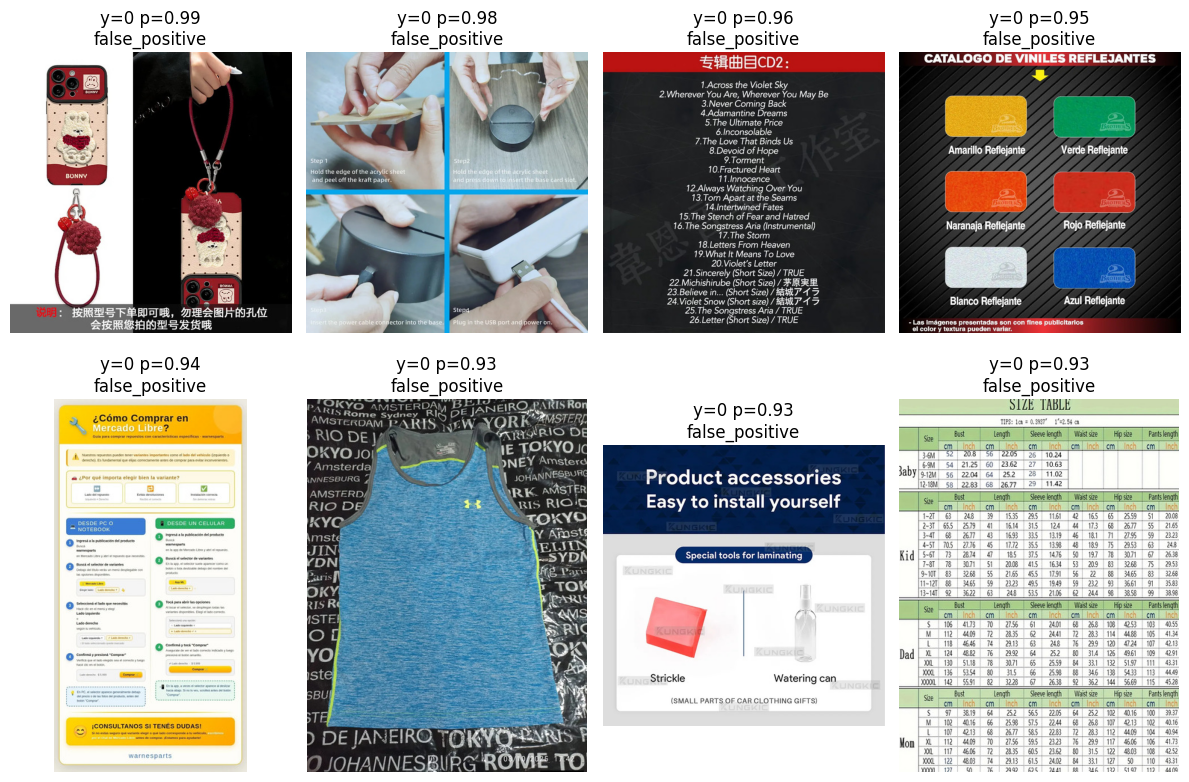

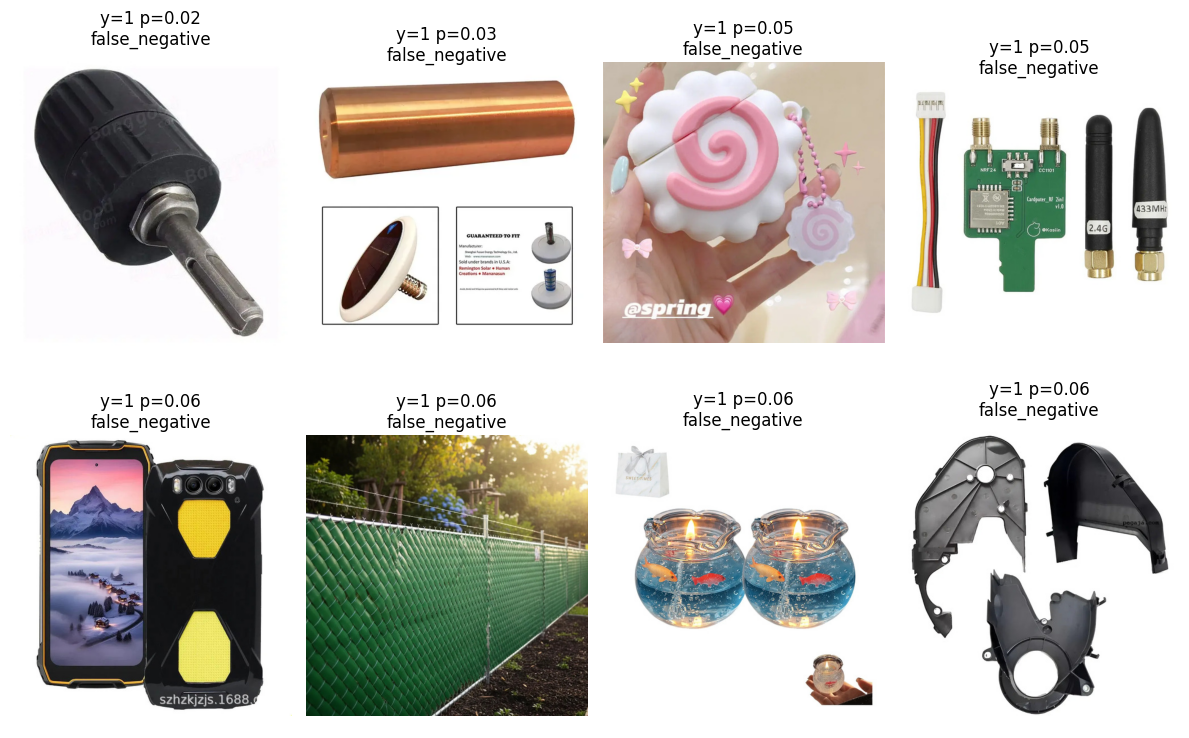

In [ ]:
# ## 16. Mirar ejemplos de errores

def show_examples(results_df, split_root, error_type, n=8):
    subset = results_df[results_df["error_type"] == error_type].copy()
    if subset.empty:
        print(f"No hay ejemplos de {error_type}")
        return

    subset = subset.sort_values("prob_contact", ascending=(error_type == "false_negative")).head(n)

    plt.figure(figsize=(12, 8))
    for i, (_, row) in enumerate(subset.iterrows()):
        image_path = Path(str(row["image_path"]))
        img_path = Path(split_root) / image_path
        if not img_path.exists():
            img_path_alt = Path(split_root).parent / image_path
            if img_path_alt.exists():
                img_path = img_path_alt
        img = Image.open(img_path).convert("RGB")
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"y={row['label']} p={row['prob_contact']:.2f}\n{error_type}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_examples(test_results, DATASET_DIR / "test", "false_positive", n=8)
show_examples(test_results, DATASET_DIR / "test", "false_negative", n=8)

In [ ]:
# ## 17. Función simple de inferencia para una imagen nueva

def predict_image(image_path, threshold=BEST_THRESHOLD):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    x = val_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()

    pred = int(prob >= threshold)
    return {
        "image_path": str(image_path),
        "prob_contact": prob,
        "pred": pred,
        "threshold": threshold,
    }

In [ ]:
# Ejemplo:
predict_image("/content/dataset_imagenes/test/images/test_000001.jpg")

{'image_path': '/content/dataset_imagenes/test/images/test_000001.jpg',
 'prob_contact': 0.4456740915775299,
 'pred': 0,
 'threshold': 0.71}

In [ ]:
print("Mejor epoch según val_auc_pr:", checkpoint["epoch"])
print("Mejor val_auc_pr:", checkpoint["val_auc_pr"])

Mejor epoch según val_auc_pr: 6
Mejor val_auc_pr: 0.6264482195300302
